In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': 'ml_pipeline_db',
    'user': 'postgres',
    'password': 'root' 
}

CONNECTION_STRING = (
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
engine = create_engine(CONNECTION_STRING)

In [2]:
df_raw = pd.read_csv(r"C:\Users\qurba\OneDrive\Desktop\SeoulBikeData.csv", encoding='latin1')

df_raw.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df_raw.to_sql('raw_data', con=engine, if_exists='replace', index=False)

760

In [6]:
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]', '_', regex=True)
    .str.replace(r'_+', '_', regex=True)
    .str.strip('_')
)

print(df_raw.columns)
print(df_raw.columns)
df_raw.to_sql('raw_data', con=engine, if_exists='replace', index=False, method='multi')

Index(['date', 'rented_bike_count', 'hour', 'temperature_c', 'humidity',
       'wind_speed_m_s', 'visibility_10m', 'dew_point_temperature_c',
       'solar_radiation_mj_m2', 'rainfall_mm', 'snowfall_cm', 'seasons',
       'holiday', 'functioning_day'],
      dtype='str')
Index(['date', 'rented_bike_count', 'hour', 'temperature_c', 'humidity',
       'wind_speed_m_s', 'visibility_10m', 'dew_point_temperature_c',
       'solar_radiation_mj_m2', 'rainfall_mm', 'snowfall_cm', 'seasons',
       'holiday', 'functioning_day'],
      dtype='str')


8760

In [8]:
# Məlumatın ümumi strukturuna baxmaq üçün (Sütun adları, tipləri və s.)
print(df_raw.info())

# Boş (null) dəyərlərin sayını yoxlamaq üçün
print(f'Null values:\n{df_raw.isnull().sum()}')

# Təkrarlanan sətirlərin sayını yoxlamaq üçün
print(f'Duplicated rows: {df_raw.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     8760 non-null   str    
 1   rented_bike_count        8760 non-null   int64  
 2   hour                     8760 non-null   int64  
 3   temperature_c            8760 non-null   float64
 4   humidity                 8760 non-null   int64  
 5   wind_speed_m_s           8760 non-null   float64
 6   visibility_10m           8760 non-null   int64  
 7   dew_point_temperature_c  8760 non-null   float64
 8   solar_radiation_mj_m2    8760 non-null   float64
 9   rainfall_mm              8760 non-null   float64
 10  snowfall_cm              8760 non-null   float64
 11  seasons                  8760 non-null   str    
 12  holiday                  8760 non-null   str    
 13  functioning_day          8760 non-null   str    
dtypes: float64(6), int64(4), str(4)
mem

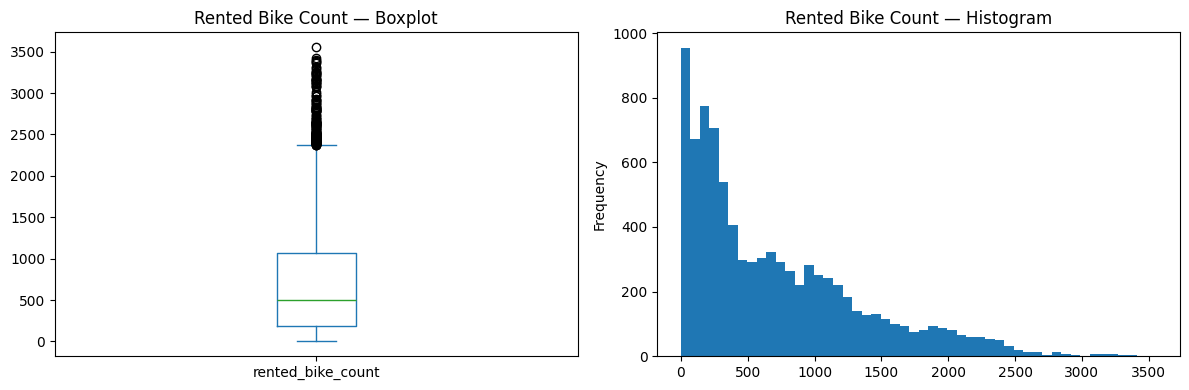

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_raw['rented_bike_count'].plot(kind='box', ax=axes[0], title='Rented Bike Count — Boxplot')
df_raw['rented_bike_count'].plot(kind='hist', bins=50, ax=axes[1], title='Rented Bike Count — Histogram')
plt.tight_layout()
plt.show()

In [10]:
CLEANING_SQL = """
DROP TABLE IF EXISTS cleaned_data;

CREATE TABLE cleaned_data AS
WITH
functioning AS (
    SELECT * FROM raw_data
    WHERE functioning_day = 'Yes'
),
deduped AS (
    SELECT DISTINCT ON (
        date, hour, temperature_c, humidity,
        wind_speed_m_s, rainfall_mm, snowfall_cm
    ) *
    FROM functioning
    ORDER BY date, hour
),
iqr AS (
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY rented_bike_count) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY rented_bike_count) AS q3
    FROM deduped
),
outlier_removed AS (
    SELECT n.*
    FROM deduped n, iqr
    WHERE n.rented_bike_count BETWEEN
        (iqr.q1 - 1.5 * (iqr.q3 - iqr.q1))
        AND
        (iqr.q3 + 1.5 * (iqr.q3 - iqr.q1))
)
SELECT
    TO_DATE(date, 'DD/MM/YYYY')  AS date,
    hour,
    rented_bike_count,
    temperature_c                AS temperature,
    humidity,
    wind_speed_m_s               AS wind_speed,
    visibility_10m               AS visibility,
    dew_point_temperature_c      AS dew_point_temp,
    solar_radiation_mj_m2        AS solar_radiation,
    rainfall_mm                  AS rainfall,
    snowfall_cm                  AS snowfall,
    seasons,
    CASE WHEN holiday = 'Holiday' THEN 1 ELSE 0 END AS is_holiday
FROM outlier_removed;
"""

with engine.connect() as conn:
    conn.execute(text(CLEANING_SQL))
    conn.commit()
    raw_count     = conn.execute(text('SELECT COUNT(*) FROM raw_data')).scalar()
    cleaned_count = conn.execute(text('SELECT COUNT(*) FROM cleaned_data')).scalar()

print(f'raw_data:     {raw_count} sətir')
print(f'cleaned_data: {cleaned_count} sətir')
print(f'Removed:      {raw_count - cleaned_count} sətir')

raw_data:     8760 sətir
cleaned_data: 8313 sətir
Removed:      447 sətir


In [11]:
df = pd.read_sql('SELECT * FROM cleaned_data', engine)
df.head()

,date,hour,rented_bike_count,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,seasons,is_holiday
0,2018-01-01,0,206,-3.2,40,0.5,1358,-14.9,0.0,0.0,0.0,Winter,1
1,2018-01-01,1,230,-3.3,41,0.7,2000,-14.7,0.0,0.0,0.0,Winter,1
2,2018-01-01,2,178,-3.7,42,0.9,2000,-14.7,0.0,0.0,0.0,Winter,1
3,2018-01-01,3,119,-4.0,44,1.0,2000,-14.4,0.0,0.0,0.0,Winter,1
4,2018-01-01,4,62,-4.2,53,1.1,1994,-12.3,0.0,0.0,0.0,Winter,1


In [12]:
df_fe = df.copy()


df_fe['date'] = pd.to_datetime(df_fe['date'])
df_fe['month'] = df_fe['date'].dt.month
df_fe['dayofweek'] = df_fe['date'].dt.dayofweek       
df_fe['is_weekend']= (df_fe['dayofweek'] >= 5).astype(int)


df_fe['time_of_day'] = pd.cut(
    df_fe['hour'],
    bins=[-1, 5, 11, 17, 21, 23],
    labels=['Night', 'Morning', 'Day', 'Evening', 'Nighttime']
)


df_fe['log_bike_count'] = np.log1p(df_fe['rented_bike_count'])


df_fe['temp_x_humidity'] = df_fe['temperature'] * df_fe['humidity']
df_fe['temp_x_solar'] = df_fe['temperature'] * df_fe['solar_radiation']
df_fe['wind_x_rain'] = df_fe['wind_speed']  * df_fe['rainfall']


season_map = {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3}
df_fe['season_encoded'] = df_fe['seasons'].map(season_map)

time_map = {'Night': 0, 'Morning': 1, 'Day': 2, 'Evening': 3, 'Nighttime': 4}
df_fe['time_of_day_encoded'] = df_fe['time_of_day'].map(time_map)

df_fe['is_rush_hour'] = df_fe['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

print(df_fe.shape)

df_fe.drop(columns=['date', 'time_of_day', 'seasons'], inplace=True)
df_fe.to_sql('fe_python_data', engine, if_exists='replace', index=False, method='multi')

(8313, 24)


8313

In [13]:
SQL_FE = """
DROP TABLE IF EXISTS fe_sql_data;

CREATE TABLE fe_sql_data AS
SELECT
    *,
    CASE
        WHEN hour BETWEEN 0  AND 5  THEN 0 
        WHEN hour BETWEEN 6  AND 11 THEN 1 
        WHEN hour BETWEEN 12 AND 17 THEN 2 
        WHEN hour BETWEEN 18 AND 21 THEN 3 
        ELSE 4 
    END AS time_bucket,

    CASE WHEN hour IN (7,8,9,17,18,19) THEN 1 ELSE 0 END AS is_rush_hour_sql,

    (temperature - AVG(temperature) OVER()) /
        NULLIF(STDDEV(temperature) OVER(), 0)  AS temp_zscore,

    (humidity - AVG(humidity) OVER()) /
        NULLIF(STDDEV(humidity) OVER(), 0)     AS humidity_zscore,

    AVG(rented_bike_count) OVER (
        PARTITION BY seasons
    ) AS avg_bikes_by_season,

    AVG(rented_bike_count) OVER (
        PARTITION BY hour
    ) AS avg_bikes_by_hour,

    CASE
        WHEN temperature < 0   THEN 'cold'
        WHEN temperature < 15  THEN 'mild'
        WHEN temperature < 25  THEN 'warm'
        ELSE 'hot'
    END AS temp_category,

    CASE WHEN rainfall > 0 OR snowfall > 0 THEN 1 ELSE 0 END AS bad_weather,

    NTILE(4) OVER (ORDER BY rented_bike_count) AS bike_count_quartile,

    LN(rented_bike_count + 1) AS log_bike_count_sql

FROM cleaned_data;
"""

with engine.connect() as conn:
    conn.execute(text(SQL_FE))
    conn.commit()
    count = conn.execute(text('SELECT COUNT(*) FROM fe_sql_data')).scalar()

print(count)
pd.read_sql('SELECT * FROM fe_sql_data LIMIT 3', engine)

8313


,date,hour,rented_bike_count,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,...,time_bucket,is_rush_hour_sql,temp_zscore,humidity_zscore,avg_bikes_by_season,avg_bikes_by_hour,temp_category,bad_weather,bike_count_quartile,log_bike_count_sql
0,2018-09-14,1,775,21.6,75,1.1,1671,16.9,0.0,0.0,...,0,0,0.747273,0.811809,891.149317,441.923295,warm,0,3,6.654153
1,2018-09-09,20,1930,22.9,58,2.6,2000,14.1,0.0,0.0,...,3,0,0.854736,-0.014316,891.149317,1044.097633,warm,0,4,7.565793
2,2018-09-06,20,1900,25.1,71,3.6,2000,19.4,0.0,0.0,...,3,0,1.036597,0.617427,891.149317,1044.097633,hot,0,4,7.550135


In [14]:
df_final = pd.read_sql('SELECT * FROM fe_sql_data', engine)

df_final['seasons_enc'] = df_final['seasons'].map({'Spring':0,'Summer':1,'Autumn':2,'Winter':3})
df_final['temp_cat_enc'] = df_final['temp_category'].map({'cold':0,'mild':1,'warm':2,'hot':3})

DROP_COLS = ['rented_bike_count', 'date', 'seasons', 'temp_category', 'log_bike_count_sql']
TARGET    = 'rented_bike_count'

X = df_final.drop(columns=[c for c in DROP_COLS if c in df_final.columns])
X = X.select_dtypes(include=[np.number])
y = df_final[TARGET]

print(f'number of feature : {X.shape[1]}')
print(f'Features: {X.columns.tolist()}')

number of feature : 20
Features: ['hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temp', 'solar_radiation', 'rainfall', 'snowfall', 'is_holiday', 'time_bucket', 'is_rush_hour_sql', 'temp_zscore', 'humidity_zscore', 'avg_bikes_by_season', 'avg_bikes_by_hour', 'bad_weather', 'bike_count_quartile', 'seasons_enc', 'temp_cat_enc']


In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Lasso':              Lasso(alpha=0.1),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results.append({'Model': name, 'RMSE': round(rmse,2), 'MAE': round(mae,2),
                    'R²': round(r2,4), 'CV_R²': round(cv_r2,4)})
    trained[name] = (model, y_pred)
    print(f'{name:22s} → R²: {r2:.4f} | RMSE: {rmse:.1f} | CV_R²: {cv_r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False))

Linear Regression      → R²: 0.8355 | RMSE: 234.0 | CV_R²: 0.4284
Ridge                  → R²: 0.8355 | RMSE: 234.0 | CV_R²: 0.4284
Lasso                  → R²: 0.8354 | RMSE: 234.0 | CV_R²: 0.4293
Random Forest          → R²: 0.9471 | RMSE: 132.6 | CV_R²: 0.8889
Gradient Boosting      → R²: 0.9311 | RMSE: 151.4 | CV_R²: 0.8864
            Model   RMSE    MAE     R²  CV_R²
    Random Forest 132.60  86.50 0.9471 0.8889
Gradient Boosting 151.39 105.68 0.9311 0.8864
Linear Regression 233.97 180.70 0.8355 0.4284
            Ridge 233.97 180.70 0.8355 0.4284
            Lasso 234.00 180.73 0.8354 0.4293


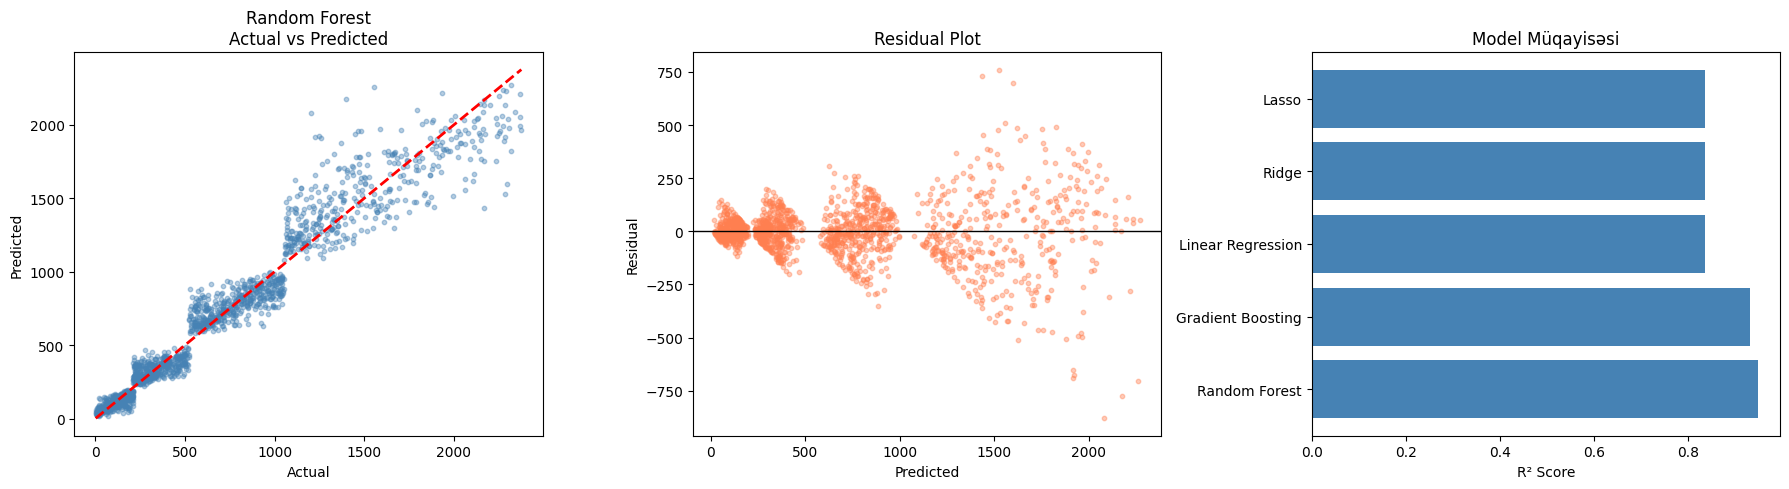

Random Forest


In [16]:
best_name  = results_df.iloc[0]['Model']
best_model, y_pred_best = trained[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name}\nActual vs Predicted')

residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='coral', s=10)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

axes[2].barh(results_df['Model'], results_df['R²'], color='steelblue')
axes[2].set_xlabel('R² Score')
axes[2].set_title('Model Müqayisəsi')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(best_name)

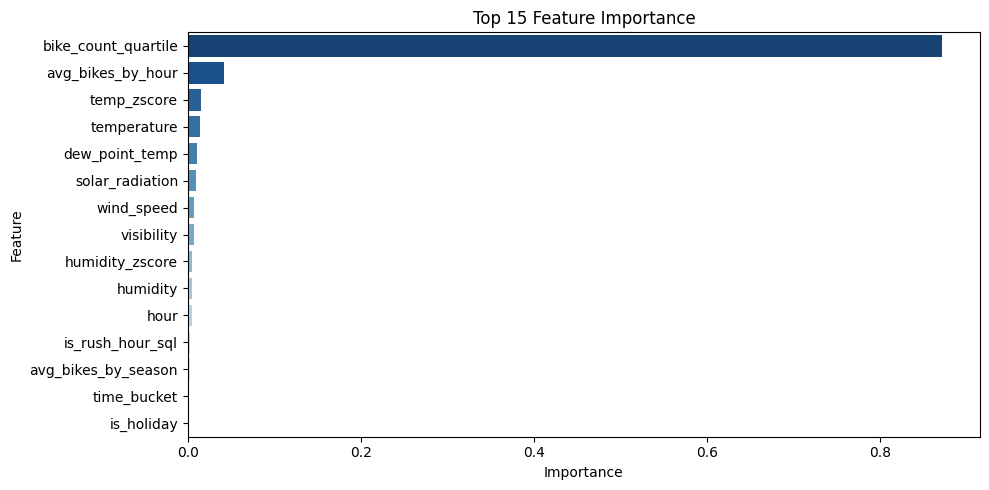

            Feature  Importance
bike_count_quartile    0.872029
  avg_bikes_by_hour    0.041857
        temp_zscore    0.014806
        temperature    0.014428
     dew_point_temp    0.011024
    solar_radiation    0.008946
         wind_speed    0.007621
         visibility    0.007361
    humidity_zscore    0.004601
           humidity    0.004421


In [17]:
# ─── Feature Importance (tree-based modelləri üçün) ─────────────────────────
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature':    X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=fi.head(15), x='Importance', y='Feature', palette='Blues_r')
    plt.title('Top 15 Feature Importance')
    plt.tight_layout()
    plt.show()
    print(fi.head(10).to_string(index=False))
elif hasattr(best_model, 'coef_'):
    coef = pd.DataFrame({
        'Feature':     X.columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print('Top 10 Koeffisiyent:')
    print(coef.head(10).to_string(index=False))

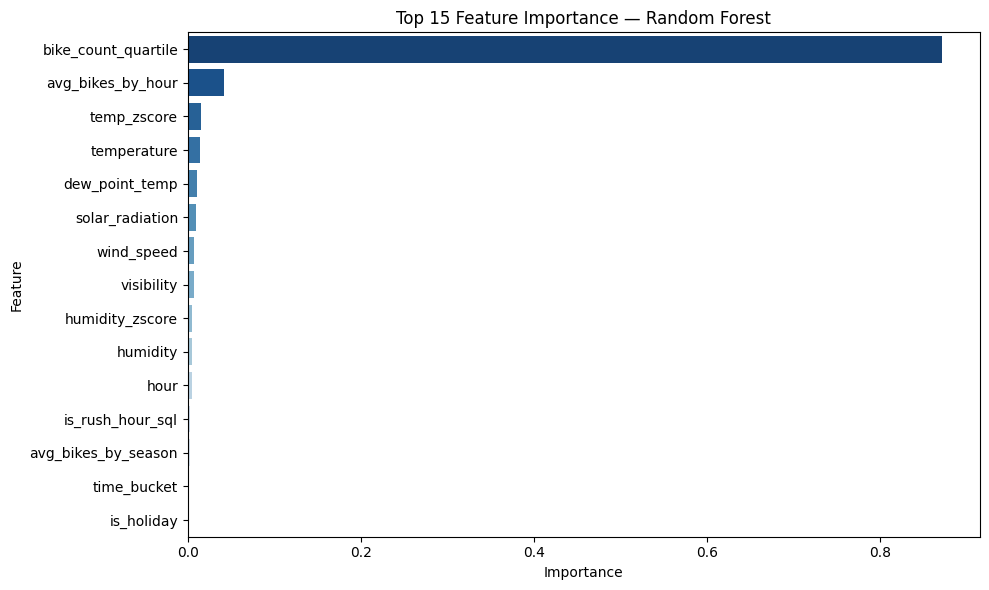

            Feature  Importance
bike_count_quartile    0.872029
  avg_bikes_by_hour    0.041857
        temp_zscore    0.014806
        temperature    0.014428
     dew_point_temp    0.011024
    solar_radiation    0.008946
         wind_speed    0.007621
         visibility    0.007361
    humidity_zscore    0.004601
           humidity    0.004421


5

In [19]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature':    X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi.head(15), x='Importance', y='Feature', palette='Blues_r')
    plt.title(f'Top 15 Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
    print(fi.head(10).to_string(index=False))

results_df.to_sql('model_results', engine, if_exists='replace', index=False)

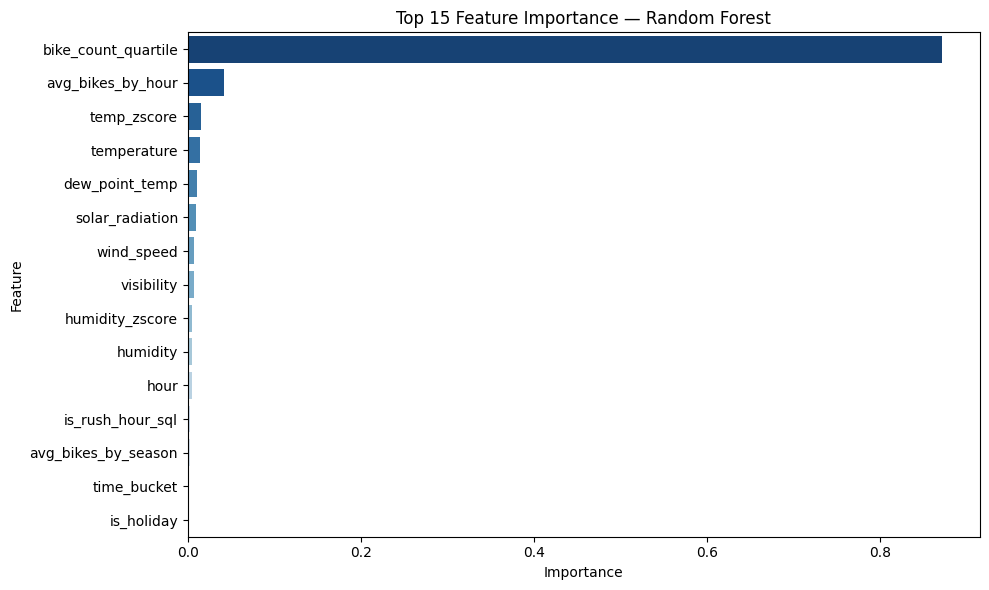

            Feature  Importance
bike_count_quartile    0.872029
  avg_bikes_by_hour    0.041857
        temp_zscore    0.014806
        temperature    0.014428
     dew_point_temp    0.011024
    solar_radiation    0.008946
         wind_speed    0.007621
         visibility    0.007361
    humidity_zscore    0.004601
           humidity    0.004421


5

In [20]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature':    X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi.head(15), x='Importance', y='Feature', palette='Blues_r')
    plt.title(f'Top 15 Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
    print(fi.head(10).to_string(index=False))

results_df.to_sql('model_results', engine, if_exists='replace', index=False)